##### ***线性数据结构***
###### 本章节我们先介绍最基础、最常用的一类数据结构：线性数据结构。<br>**常见的线性数据结构**有：<br>1. 数组：像是一排编号的储物柜，每个柜子有固定位置<br>2. 链表：像是一串手拉手的人，每个人只记住前后的人<br>3. 栈：像是一叠盘子，只能从顶部取放 <br>4. 队列：像是排队买票，先来先服务
###### 每一种线性数据结构又有具体分支，具体来说下图展示了线性结构的分类体系，每种结构都有其特定的应用场景和性能特点：
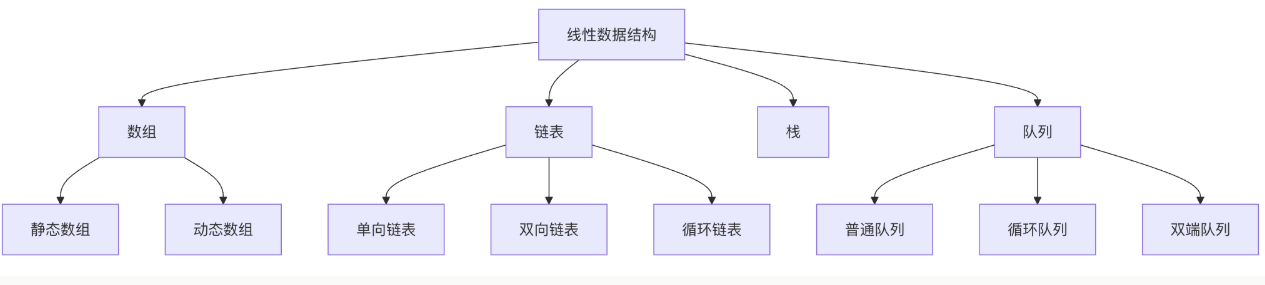
###### 接下来将具体的讲解并实现常见的各种线性数据结构。

##### ***一、数组：数据的固定公寓楼***
###### 数组是最简单、最直接的线性数据结构。我们可以把它想象成一栋 固定楼层数的公寓楼。
###### **基本概念与特点**：<br>1. 连续存储：数组在内存中占据一块 连续 的空间，就像公寓楼里房间是紧挨着的。<br>2. 固定大小：数组在创建时就需要确定其容量（长度），之后通常不能改变，就像公寓楼盖好后房间数就固定了。<br>3. 索引访问：每个元素（房间）都有一个唯一的编号，称为 索引。在大多数编程语言中，索引从 0 开始。你可以通过索引直接、快速地访问任何一个元素，时间复杂度为 O(1)。
<font size=3>

| 优点 | 缺点 |
| :---: | :---: |
| **高速随机访问**：通过索引可在常数时间内访问任何元素。 | **大小固定**：静态数组一旦创建，容量难以改变。 |
| **内存效率高**：连续存储，无需额外空间存储元素间关系。| **插入/删除成本高**：在中间插入或删除元素，需要移动大量后续元素以保持连续性。 |</font>

In [4]:
# 利用Python演示数组的核心操作
# 1. 创建数组
apartment_building = ['101室-张三', '102室-李四', '103室-王五', '104室-空置', '105室-空置']
print("公寓住宿情况：", apartment_building)

# 2. 访问数组中的元素（通过索引） 索引从0开始
tenant = apartment_building[1]
print(tenant)
# 循环遍历数组
for i in apartment_building:
    print (i, end=', ' if i != '105室-空置' else "\n")

# 3. 更新元素
# 104室搬来了新住户赵六
apartment_building[3] = '104室-赵六'
print("赵六入住后：", apartment_building[3])

# 4. 插入元素（在末尾添加）
# 假设新建了一个房间106室
apartment_building.append('106室-空置')
print("加盖106室后：", apartment_building)

# 5. 删除元素
# 103住户搬走了
# 方法一：根据数组的使用场景，按照逻辑使用数组更新操作将原本有人的房间改为空置
# apartment_building[2] = '103室-空置'
# 方法二：按照数组的逻辑，删除其中一个后，其他的位置需要迁移补充缺失
removed_tenant = apartment_building.pop(2)
print(f"{removed_tenant} 已搬走。")
print("王五搬走后：", apartment_building)


公寓住宿情况： ['101室-张三', '102室-李四', '103室-王五', '104室-空置', '105室-空置']
102室-李四
101室-张三, 102室-李四, 103室-王五, 104室-空置, 105室-空置
赵六入住后： 104室-赵六
加盖106室后： ['101室-张三', '102室-李四', '103室-王五', '104室-赵六', '105室-空置', '106室-空置']
103室-王五 已搬走。
王五搬走后： ['101室-张三', '102室-李四', '104室-赵六', '105室-空置', '106室-空置']


##### ***二、链表：数据的寻宝火车***
###### 当数组的固定大小和插入删除的低效成为问题时，链表就登场了。链表像一列 火车，每节车厢（节点）都装载着货物（数据），并通过挂钩（指针）连接下一节车厢。
###### **基本概念与类型**<br>链表的每个节点至少包含两部分：<br>1. 数据域：存储实际的数据值。<br>2. 指针域：存储下一个节点在内存中的地址。
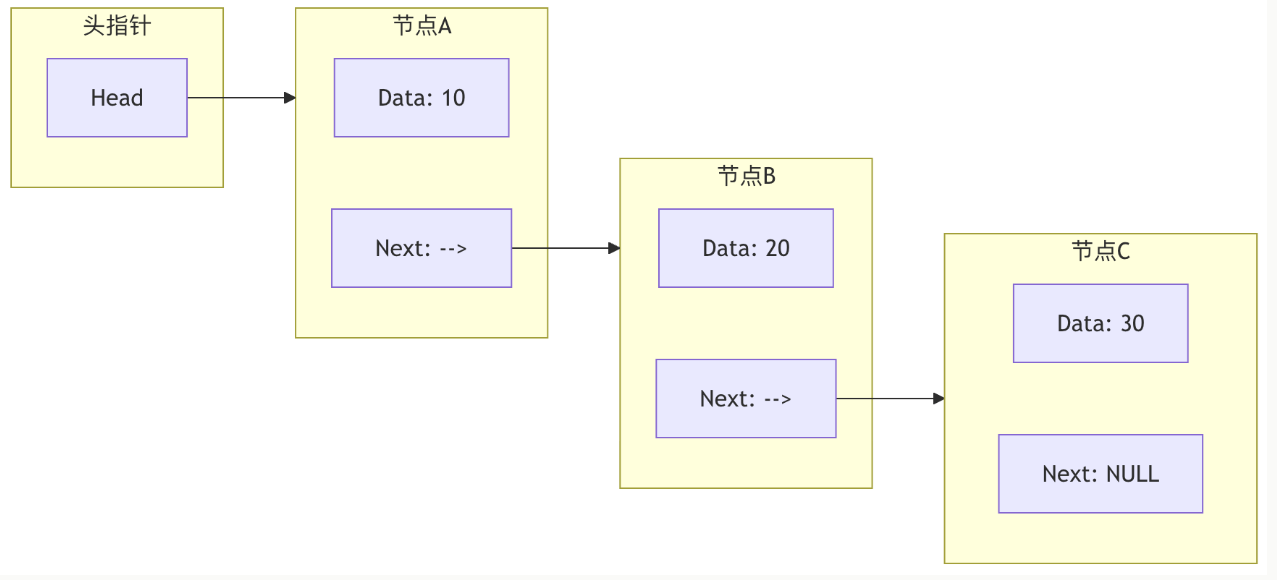
###### 上图是一个单向链表的结构，头指针指向第一个节点，而每个节点中除了数据外还有一个next指针用于指向下一个节点，而最后一个节点的next指针指空，表示链表结束。除单向链表外，还有双向链表（节点中的指针同时指向前一个和后一个节点，可以双向遍历）和循环链表（尾节点指向头节点形成一个环）

In [5]:
# 利用Python实现一个简单的单向链表
# 1. 创建一个节点类
class ListNode:
    def __init__(self, data):
        self.data = data # 数据域
        self.next = None # 指针域，初始化为空

# 2. 创建一个链表类
class LinkedList:
    def __init__(self):
        self.head = None

    def append(self, data):
        # 在链表末尾添加节点
        new_node = ListNode(data)
        if not self.head: # 如果没有头指针，说明链表为空，这个添加的节点是头节点。
            self.head = new_node
            return 
        # 如果不是空链表，我们需要找到最后一个节点
        last_node = self.head # 首先假设最后一个节点是头节点
        while last_node.next:
            last_node = last_node.next
        last_node.next = new_node

    def prepend(self, data):
        # 在链表头部添加节点
        new_node = ListNode(data)
        new_node.next = self.head # 这里将new_node的next指针指向head是因为，添加节点需要将new_node的next指针指向原本的第一个节点，而head正好就指向原本的第一个节点，所以直接让new_node指向head即可，然后将head的指向修改指向new_node
        self.head = new_node

    def delete(self, key):
        # 删除第一个值为key的节点
        current_node = self.head

        # 如果要删除的是头节点
        if current_node and current_node.data == key:
            self.head = current_node.next
            current_node = None

        prev_node = None # 需要一个节点来定位current_node走到哪了
        # 如果要删除的不是头节点，则要遍历
        while current_node and current_node.data != key:
            prev_node = current_node
            current_node = current_node.next

        if current_node is None: # 如果没找到
            return

        # 如果找到了，就绕过该节点，连接后面的节点
        prev_node.next = current_node.next
        current_node = None

    def print_list(self):
        # 打印链表里的所有元素
        current_node = self.head
        while current_node:
            print(current_node.data, end=" -> ")
            current_node = current_node.next
        print("NULL")

###### 关于链表的操作，为方便理解，请看如下图示：
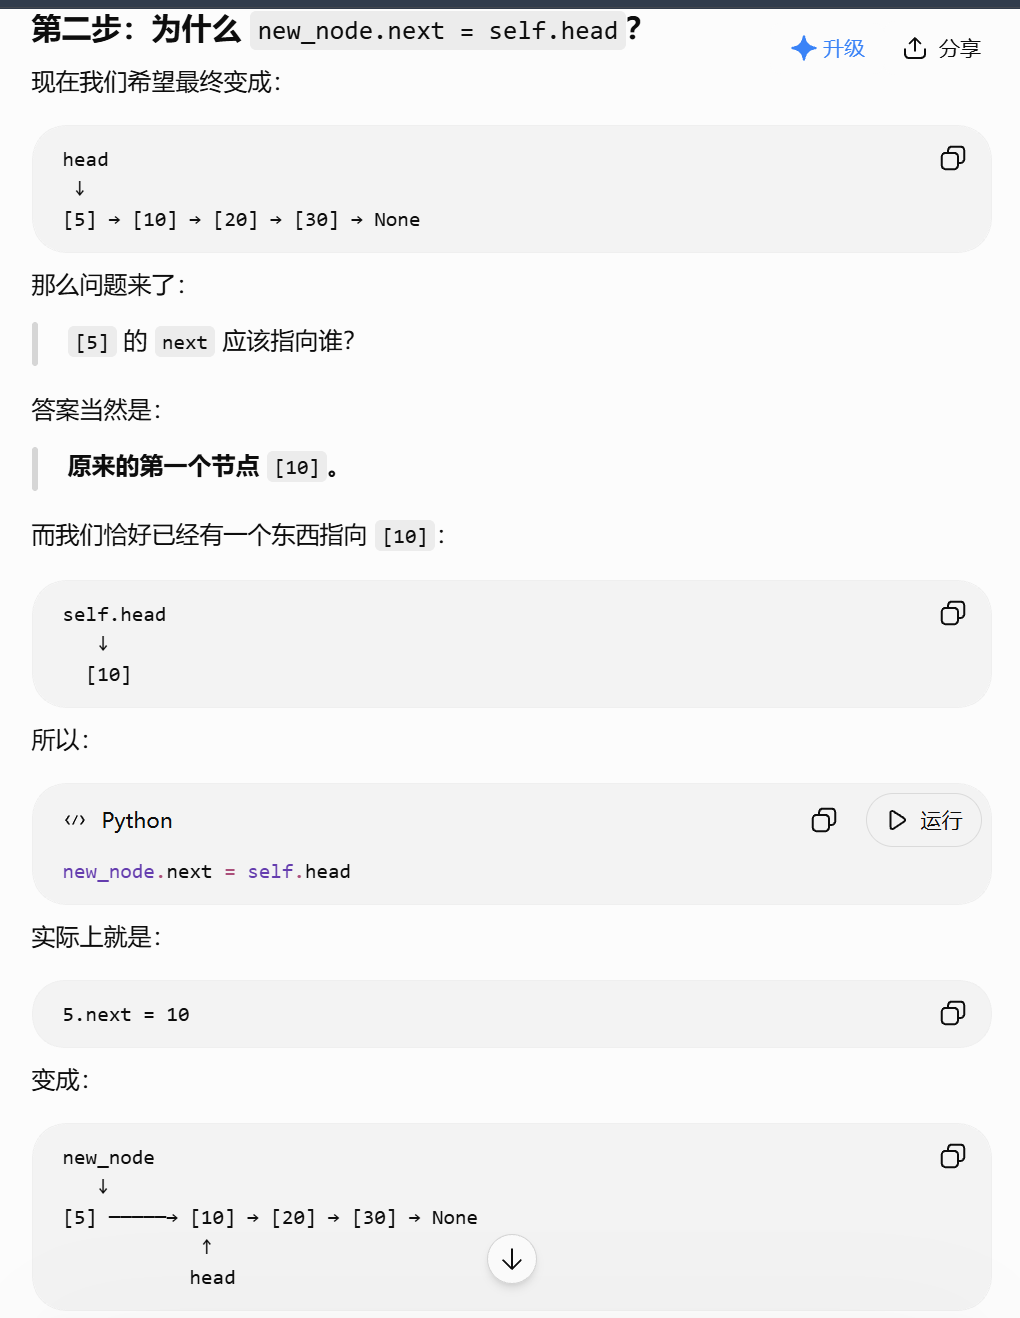
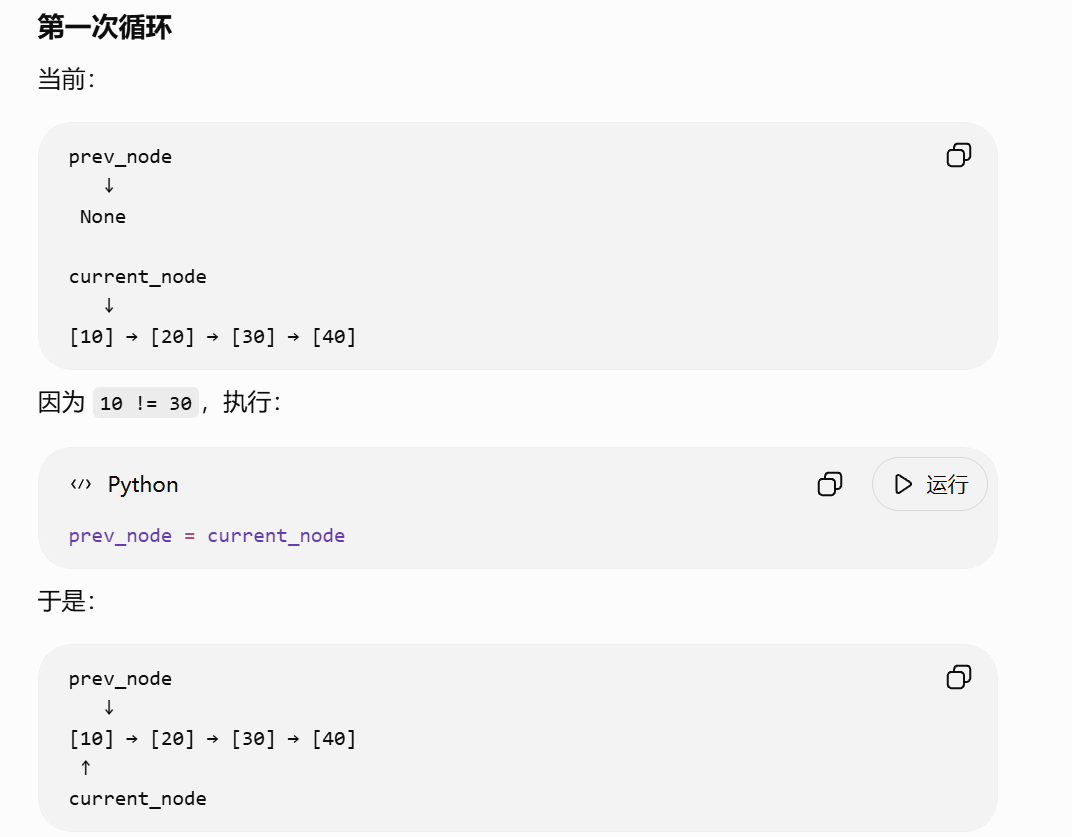

In [6]:
# 测试链表
print("=== 单向链表操作演示 ===")
train = LinkedList()
train.append("车厢1-煤炭")
train.append("车厢2-木材")
train.prepend("车头")  # 在头部添加
train.append("车厢3-钢材")
print("初始列车：")
train.print_list()  # 输出：车头 -> 车厢1-煤炭 -> 车厢2-木材 -> 车厢3-钢材 -> NULL

train.delete("车厢2-木材")
print("卸下木材后：")
train.print_list()  # 输出：车头 -> 车厢1-煤炭 -> 车厢3-钢材 -> NULL

=== 单向链表操作演示 ===
初始列车：
车头 -> 车厢1-煤炭 -> 车厢2-木材 -> 车厢3-钢材 -> NULL
卸下木材后：
车头 -> 车厢1-煤炭 -> 车厢3-钢材 -> NULL


<font size=3>

| 优点 | 缺点 |
| :---: | :---: |
| **动态大小**：无需预先分配固定空间，可以灵活地增长和缩小。 | **内存开销**：每个节点都需要额外空间存储指针。 |
| **高效插入/删除**：在已知节点位置时，只需修改指针，无需移动大量元素。| **顺序访问**：无法像数组一样通过索引直接访问，必须从头开始遍历。|
| ---| **缓存不友好**：节点在内存中分散存储，不利于CPU缓存预取。 |</font>

##### ***栈：数据的叠盘子***
###### 栈是一种 后进先出 的数据结构，就像餐厅里叠放的盘子，你总是取走最上面的那个（最后放上去的）。
###### **基本概念与操作**<br>栈只允许在一端（称为 栈顶）进行插入（入栈）和删除（出栈）操作。另一端称为 栈底。**核心操作：**<br>1. push(data)：将数据压入栈顶。<br>2. pop()：弹出并返回栈顶元素。<br>3. peek() / top()：查看栈顶元素但不弹出。<br>4. is_empty()：检查栈是否为空。
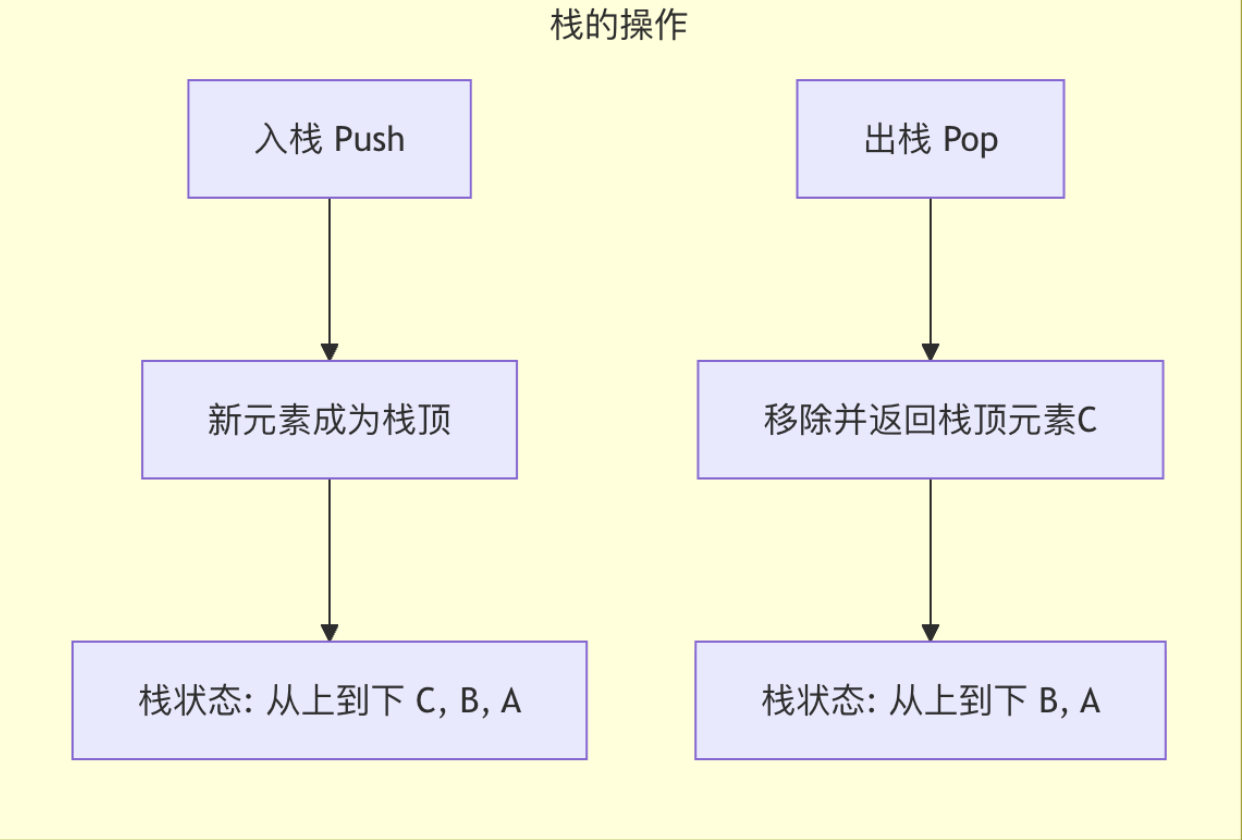

In [8]:
# 利用Python实现栈的定义与相关操作
class Stack:
    # 使用列表实现栈
    def __init__(self):
        self.items = []
    
    def push(self, item):
        # 入栈操作
        self.items.append(item)
    
    def pop(self):
        # 出栈操作，如果栈空则返回None
        if not self.is_empty():
            return self.items.pop()
        return None
    
    def peek(self):
        # 查看栈顶元素
        if not self.is_empty():
            return self.items[-1]
        return None
    
    def is_empty(self):
        # 检查栈是否为空
        return len(self.items) == 0
    
    def size(self):
        return len(self.items)
    
# 应用示例：括号匹配检查
def is_balanced_parentheses(expression):
    # 检查表达式中的括号是否匹配
    stack = Stack()
    # 括号匹配映射
    matching_bracket = {')': '(', ']': '[', '}': '{'}

    for char in expression:
        if char in '({[': # 如果第一个是左括号，才入栈进行检查
            stack.push(char)
        elif char in ')}]': # 如果第一个是右括号，则需检查栈是否为空
            if stack.is_empty(): # 为空说明该表达式天生括号不匹配
                return False
            # 否则检查栈中是否有左括号匹配
            top_char = stack.pop()
            if matching_bracket[char] != top_char:
                return False
    # 循环结束后，栈应该为空，否则不匹配
    return stack.is_empty()
            
# 测试栈和括号匹配
print("\n=== 栈与括号匹配演示 ===")
plate_stack = Stack()
plate_stack.push("盘子1")
plate_stack.push("盘子2")
plate_stack.push("盘子3")
print(f"取出最上面的盘子: {plate_stack.pop()}")  # 输出：盘子3
print(f"现在最上面的盘子是: {plate_stack.peek()}")  # 输出：盘子2

# 测试括号匹配
test_cases = ["((1+2)*3)", "({[ ]})", "((())", ")( )"]
for test in test_cases:
    result = "平衡" if is_balanced_parentheses(test) else "不平衡"
    print(f"表达式 '{test}' 的括号是 {result} 的。")


=== 栈与括号匹配演示 ===
取出最上面的盘子: 盘子3
现在最上面的盘子是: 盘子2
表达式 '((1+2)*3)' 的括号是 平衡 的。
表达式 '({[ ]})' 的括号是 平衡 的。
表达式 '((())' 的括号是 不平衡 的。
表达式 ')( )' 的括号是 不平衡 的。


##### ***队列：数据的排队通道***
###### 队列是一种 先进先出 的数据结构，就像生活中任何需要排队的地方（如超市收银台），先来的人先接受服务。
###### **基本概念与操作**<br>队列允许在一端（称为 队尾）进行插入（入队）操作，在另一端（称为 队头）进行删除（出队）操作。<br>**核心操作：**<br>1. enqueue(data)：将数据加入队尾。<br>2. dequeue()：从队头移除并返回数据。<br>3. front() / peek()：查看队头数据但不移除。<br>4. is_empty()：检查队列是否为空。

In [9]:
# 利用Python实现队列及其相关操作
from collections import deque # 使用Python双端队列，提供了高效的头尾操作

class Queue:
    # 使用collections.deque实现队列
    def __init__(self):
        self.items = deque()
    
    def enqueue(self, item):
        # 入队操作
        self.items.append(item) # 从队尾添加
    
    def dequeue(self):
        # 出队操作，如果队空则返回None
        if not self.is_empty():
            return self.items.popleft() # 从队头移出
        return None
    
    def front(self):
        # 查看队头元素
        if not self.is_empty():
            return self.items[0]
    
    def is_empty(self):
        return len(self.items) == 0

    def size(self):
        return len(self.items)
        
# 应用示例：模拟打印任务
print("\n=== 队列与打印任务模拟 ===")
printer_queue = Queue()

# 模拟三个打印任务到达
tasks = ["Alice的简历.pdf", "Bob的报告.doc", "Charlie的图表.png"]
for task in tasks:
    printer_queue.enqueue(task)
    print(f"任务 '{task}' 已加入打印队列。")

# 处理打印任务
print("\n开始打印...")
while not printer_queue.is_empty():
    current_task = printer_queue.dequeue()
    print(f"正在打印: {current_task}")
    # 模拟打印耗时
print("所有打印任务已完成。")


=== 队列与打印任务模拟 ===
任务 'Alice的简历.pdf' 已加入打印队列。
任务 'Bob的报告.doc' 已加入打印队列。
任务 'Charlie的图表.png' 已加入打印队列。

开始打印...
正在打印: Alice的简历.pdf
正在打印: Bob的报告.doc
正在打印: Charlie的图表.png
所有打印任务已完成。


##### ***总结与对比***
<font size=3>

| 特性 | 数组 | 链表 | 栈 | 队列 |
| :---: | :---: | :---: | :---: | :---: |
| **存储方式** | 连续内存 | 分散内存，通过指针连接 | 基于数组或链表实现 | 基于数组或链表实现 |
| **访问方式**| 随机访问（通过索引） | 顺序访问（必须遍历） | 仅限栈顶（LIFO，后进先出） | 仅限队头（FIFO，先进先出） |
|**插入/删除效率** | 尾部快，中间/头部慢（需移动元素） | 已知位置时快（只需改指针） | 栈顶操作，O(1)	 | 队尾入队，队头出队，O(1) |
|**大小** | 固定（静态数组） | 动态 | 动态	 | 动态 |
|**主要应用** | 快速查找、固定集合 | 频繁插入删除、不确定大小 | 函数调用、回溯、括号匹配	 | 任务调度、缓冲、BFS |</font>